# 🎬 Cinematic Sentiment AI — Master Notebook

A complete NLP pipeline for binary sentiment classification of movie reviews.

**Pipeline:** Preprocessing → Feature Engineering → ML Baselines → Deep Learning (RNN/LSTM/GRU/Bi-LSTM + GloVe) → Transformer (RoBERTa) → LLM Explanations (Gemini) → RAG (FAISS) → LangChain Agent → Gradio UI

**Dataset:** IMDB 50K Movie Reviews (25K positive, 25K negative)


## 0. Setup & Installation

We install all the libraries needed across the entire pipeline:
- **sklearn** — ML baselines (Logistic Regression, SVM, Naive Bayes, Random Forest)
- **tensorflow/keras** — Deep Learning (RNN, LSTM, GRU, Bi-LSTM)
- **transformers + torch** — Transformer fine-tuning (RoBERTa)
- **google-generativeai** — LLM explanations (Gemini API)
- **sentence-transformers + faiss** — RAG retrieval pipeline
- **langchain** — Agent with dynamic tool calling
- **gradio** — Interactive web UI


In [1]:
!pip install -q transformers torch datasets accelerate kagglehub nltk gensim
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q sentence-transformers faiss-cpu gradio
!pip install -q langchain langchain-google-genai google-generativeai

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, json
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, roc_auc_score)

print("All libraries loaded successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.4 MB/s eta 0:00:00
All libraries loaded successfully!


## 1. Data Loading

We use `kagglehub` to download the **IMDB 50K Movie Reviews** dataset directly from Kaggle.

This dataset contains 50,000 movie reviews from IMDB, perfectly balanced between 25,000 positive and 25,000 negative reviews. Each review is labeled with a `sentiment` column (`positive` or `negative`).


In [2]:
import kagglehub

path_imdb = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print("Dataset path:", path_imdb)

csv_file = None
for root, dirs, files in os.walk(path_imdb):
    for f in files:
        if f.endswith('.csv'):
            csv_file = os.path.join(root, f)
            break

df_imdb = pd.read_csv(csv_file)
print(f"Shape: {df_imdb.shape}")
print(f"Columns: {df_imdb.columns.tolist()}")
df_imdb.head()


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset path: /kaggle/input/imdb-dataset-of-50k-movie-reviews
Shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 1.5 Exploratory Data Analysis (EDA)

Before preprocessing, we explore the raw dataset to understand:
- **Class distribution** — Is the dataset balanced?
- **Review lengths** — How long are the reviews? This affects our sequence length choices.
- **Common words** — What words appear most frequently in positive vs negative reviews?
- **Missing values** — Any data quality issues?


In [3]:
# Basic statistics
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total reviews: {len(df_imdb)}")
print(f"Columns: {df_imdb.columns.tolist()}")
print(f"Missing values:\n{df_imdb.isnull().sum()}")
print(f"Duplicates: {df_imdb.duplicated().sum()}")
print(f"\nData types:\n{df_imdb.dtypes}")
print(f"\nClass distribution:\n{df_imdb['sentiment'].value_counts()}")


DATASET OVERVIEW
Total reviews: 50000
Columns: ['review', 'sentiment']
Missing values:
review       0
sentiment    0
dtype: int64
Duplicates: 418

Data types:
review       object
sentiment    object
dtype: object

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


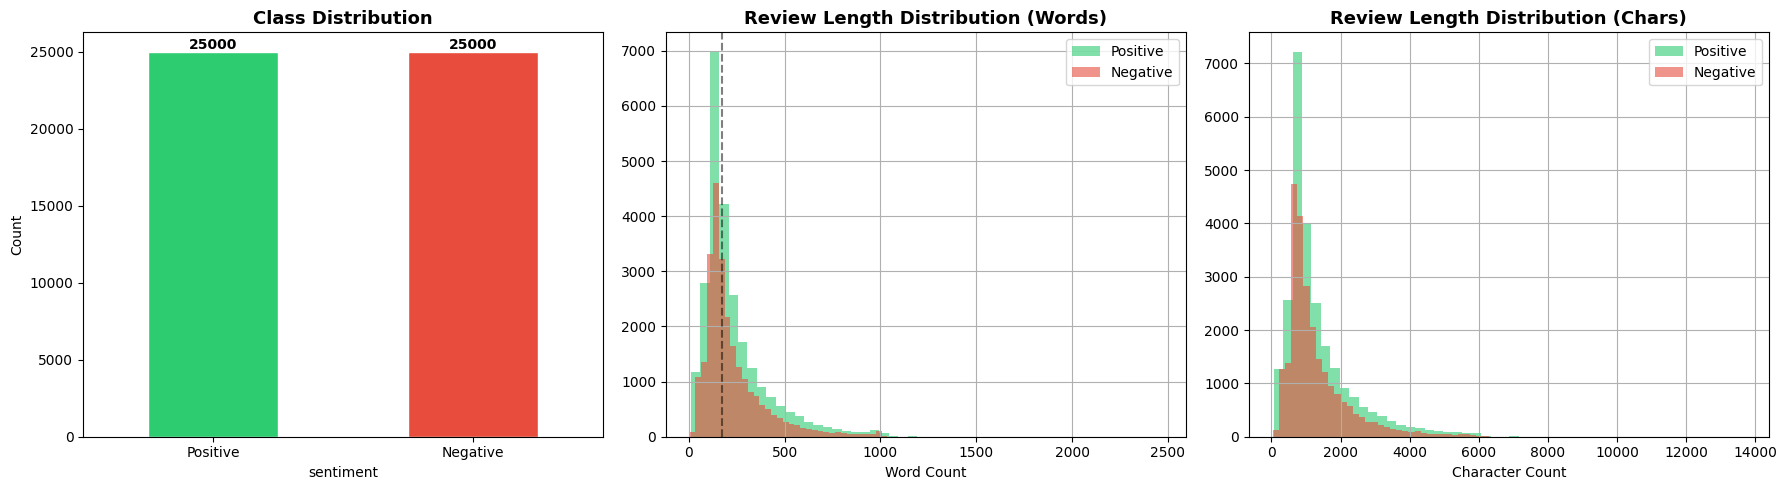


Review Length Stats (words):
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000


In [4]:
# Class Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sentiment count
colors = ['#2ecc71', '#e74c3c']
df_imdb['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Positive', 'Negative'], rotation=0)
for i, v in enumerate(df_imdb['sentiment'].value_counts()):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# 2. Review length (words)
df_imdb['word_count_raw'] = df_imdb['review'].apply(lambda x: len(x.split()))
df_imdb[df_imdb['sentiment']=='positive']['word_count_raw'].hist(
    ax=axes[1], bins=50, alpha=0.6, color='#2ecc71', label='Positive')
df_imdb[df_imdb['sentiment']=='negative']['word_count_raw'].hist(
    ax=axes[1], bins=50, alpha=0.6, color='#e74c3c', label='Negative')
axes[1].set_title('Review Length Distribution (Words)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Word Count')
axes[1].legend()
axes[1].axvline(x=df_imdb['word_count_raw'].median(), color='black', linestyle='--', alpha=0.5, label='Median')

# 3. Review length (characters)
df_imdb['char_count_raw'] = df_imdb['review'].apply(len)
df_imdb[df_imdb['sentiment']=='positive']['char_count_raw'].hist(
    ax=axes[2], bins=50, alpha=0.6, color='#2ecc71', label='Positive')
df_imdb[df_imdb['sentiment']=='negative']['char_count_raw'].hist(
    ax=axes[2], bins=50, alpha=0.6, color='#e74c3c', label='Negative')
axes[2].set_title('Review Length Distribution (Chars)', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Character Count')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nReview Length Stats (words):")
print(df_imdb['word_count_raw'].describe().to_string())


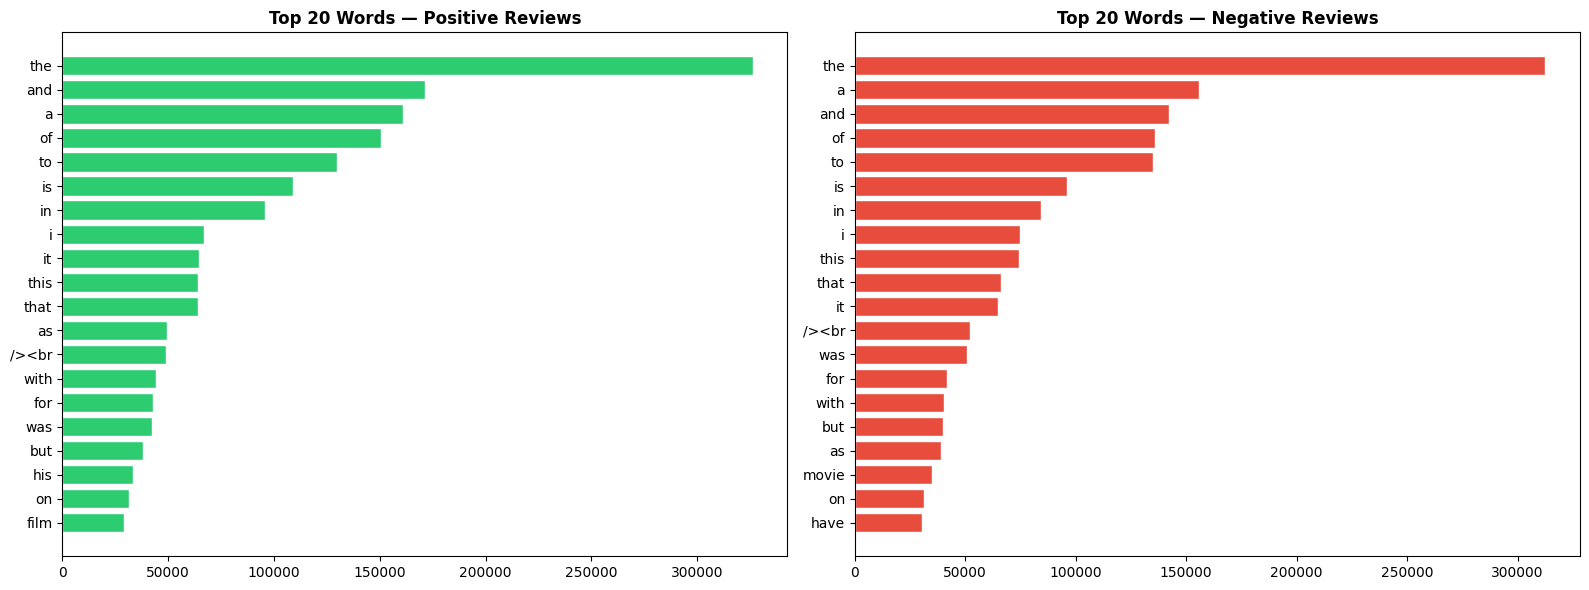

In [5]:
# Top words by sentiment
from collections import Counter

def get_top_words(texts, n=20):
    all_words = ' '.join(texts).lower().split()
    return Counter(all_words).most_common(n)

pos_reviews = df_imdb[df_imdb['sentiment']=='positive']['review'].values
neg_reviews = df_imdb[df_imdb['sentiment']=='negative']['review'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive
top_pos = get_top_words(pos_reviews, 20)
words, counts = zip(*top_pos)
axes[0].barh(words[::-1], counts[::-1], color='#2ecc71', edgecolor='white')
axes[0].set_title('Top 20 Words — Positive Reviews', fontweight='bold')

# Negative
top_neg = get_top_words(neg_reviews, 20)
words, counts = zip(*top_neg)
axes[1].barh(words[::-1], counts[::-1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 20 Words — Negative Reviews', fontweight='bold')

plt.tight_layout()
plt.show()


In [6]:
# Sample reviews
print("="*60)
print("SAMPLE POSITIVE REVIEWS")
print("="*60)
for i, row in df_imdb[df_imdb['sentiment']=='positive'].head(3).iterrows():
    print(f"\n[{i}] {row['review'][:200]}...")

print("\n" + "="*60)
print("SAMPLE NEGATIVE REVIEWS")
print("="*60)
for i, row in df_imdb[df_imdb['sentiment']=='negative'].head(3).iterrows():
    print(f"\n[{i}] {row['review'][:200]}...")

# Cleanup temp columns
df_imdb.drop(columns=['word_count_raw', 'char_count_raw'], inplace=True)


SAMPLE POSITIVE REVIEWS

[0] One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

[1] A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece...

[2] I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is wi...

SAMPLE NEGATIVE REVIEWS

[3] Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, J...

[7] This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were

## 2. Text Preprocessing

This is one of the most critical steps. We clean the raw text to remove noise while preserving sentiment-carrying information.

**Steps applied:**
1. **Remove HTML tags** — IMDB reviews contain `<br/>` tags from web scraping
2. **Lowercase** — Standardize all text
3. **Remove special characters & digits** — Keep only alphabetic characters
4. **Tokenize** — Split text into individual words using NLTK
5. **Negation-aware stopword removal** — We remove common words ('the', 'is', 'a') BUT explicitly keep negation words ('not', 'no', 'never', "don't") because they flip sentiment
6. **Lemmatization** — Reduce words to root form ('running' → 'run', 'better' → 'good')


In [7]:
lemmatizer = WordNetLemmatizer()

# Build negation-aware stopword set
# This is critical: removing 'not' from 'not good' would flip the meaning!
negation_words = {'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing',
                  'nowhere', 'none', "don't", "doesn't", "didn't", "won't",
                  "wouldn't", "couldn't", "shouldn't", "isn't", "aren't",
                  "wasn't", "weren't", "hasn't", "haven't", "hadn't",
                  "can't", "cannot", "mustn't", "needn't"}
stop_words = set(stopwords.words('english')) - negation_words

def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)           # Remove HTML tags
    text = text.lower()                            # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)           # Remove non-alpha
    tokens = word_tokenize(text)                   # Tokenize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

print("Cleaning reviews (this takes ~1 minute)...")
df_imdb['clean_review'] = df_imdb['review'].apply(clean_text)
df_imdb['label'] = (df_imdb['sentiment'] == 'positive').astype(int)

print("\nBefore vs After cleaning:")
print(f"  Original: {df_imdb['review'].iloc[0][:100]}...")
print(f"  Cleaned:  {df_imdb['clean_review'].iloc[0][:100]}...")
print(f"\nDone! {len(df_imdb)} reviews cleaned.")


Cleaning reviews (this takes ~1 minute)...

Before vs After cleaning:
  Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. The...
  Cleaned:  one reviewer mentioned watching episode youll hooked right exactly happened methe first thing struck...

Done! 50000 reviews cleaned.


## 3. Feature Engineering

We extract **7 linguistic features** from the **original** (uncleaned) reviews.

These features capture writing style patterns that correlate with sentiment:
- **word_count** / **char_count** — Negative reviews tend to be longer (people rant more when unhappy)
- **punct_count** — Emotional reviews use more punctuation
- **exclamation_count** — Excitement or frustration indicator
- **question_count** — Rhetorical questions often signal criticism
- **capital_ratio** — SHOUTING indicates strong emotion
- **avg_word_length** — More sophisticated vocabulary may correlate with nuanced reviews


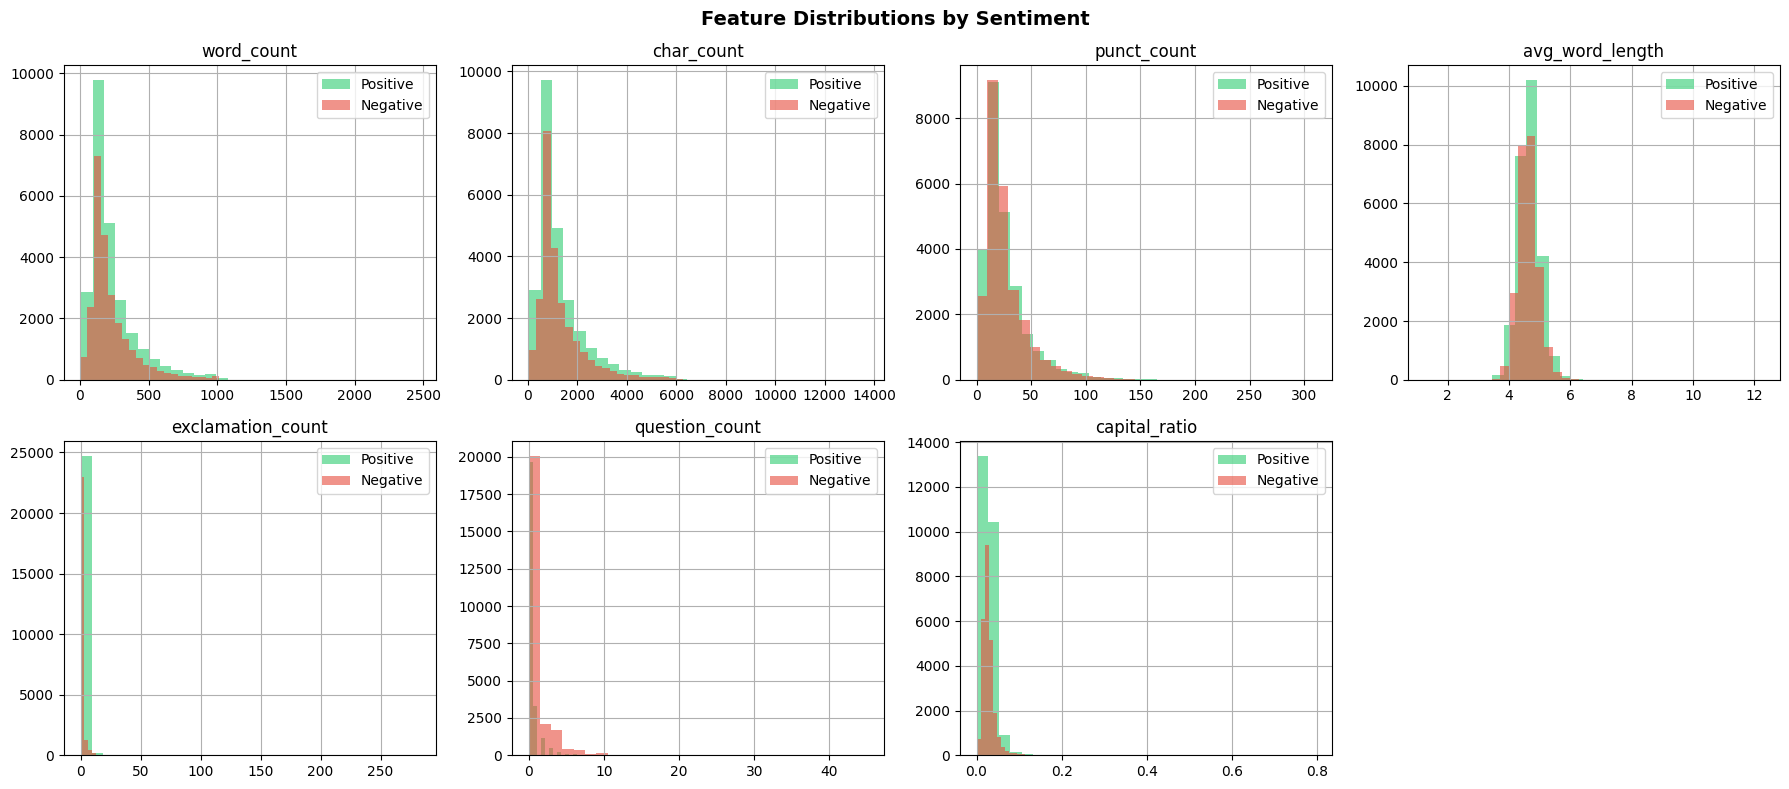

In [8]:
df_imdb['word_count'] = df_imdb['review'].apply(lambda x: len(x.split()))
df_imdb['char_count'] = df_imdb['review'].apply(len)
df_imdb['punct_count'] = df_imdb['review'].apply(lambda x: sum(1 for c in x if c in '.,!?;:'))
df_imdb['avg_word_length'] = df_imdb['review'].apply(lambda x: np.mean([len(w) for w in x.split()]))
df_imdb['exclamation_count'] = df_imdb['review'].apply(lambda x: x.count('!'))
df_imdb['question_count'] = df_imdb['review'].apply(lambda x: x.count('?'))
df_imdb['capital_ratio'] = df_imdb['review'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))

feature_cols = ['word_count', 'char_count', 'punct_count', 'avg_word_length',
                'exclamation_count', 'question_count', 'capital_ratio']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    ax = axes[i]
    df_imdb[df_imdb['label']==1][col].hist(ax=ax, alpha=0.6, label='Positive', bins=30, color='#2ecc71')
    df_imdb[df_imdb['label']==0][col].hist(ax=ax, alpha=0.6, label='Negative', bins=30, color='#e74c3c')
    ax.set_title(col)
    ax.legend()
axes[-1].axis('off')
plt.suptitle('Feature Distributions by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Train / Test Split

We split the data 80/20 (40,000 train, 10,000 test) with `random_state=42` for reproducibility.

The split is stratified by default since the dataset is perfectly balanced (25K/25K).


In [9]:
X = df_imdb['clean_review'].values
y = df_imdb['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Train positive ratio: {y_train.mean():.2%}")
print(f"Test positive ratio: {y_test.mean():.2%}")


Train: 40000, Test: 10000
Train positive ratio: 49.90%
Test positive ratio: 50.39%


## 5. Machine Learning Baselines

We use **TF-IDF** (Term Frequency-Inverse Document Frequency) to convert text into numerical vectors.

**How TF-IDF works:**
- **TF** — How often a word appears in a document (high = important to this review)
- **IDF** — How rare a word is across ALL documents (high = more distinctive)
- **TF × IDF** — Words that are frequent in ONE review but rare overall get the highest scores

We use `max_features=5000` (top 5K words) and `ngram_range=(1,2)` to capture both single words ('great') and bigrams ('not good').

**4 classifiers:**
- **Logistic Regression** — Linear model, excellent baseline for text
- **Linear SVM** — Finds the optimal separating hyperplane
- **Naive Bayes** — Probabilistic, assumes word independence
- **Random Forest** — Ensemble of decision trees


In [10]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

ml_results = {}
ml_preds = {}

for name, model in ml_models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    ml_results[name] = acc
    ml_preds[name] = preds
    print(f"{name}: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=['Negative', 'Positive']))
    print()


Logistic Regression: 0.8888
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4961
    Positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Linear SVM: 0.8851
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      4961
    Positive       0.88      0.89      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Naive Bayes: 0.8581
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4961
    Positive       0.85      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weigh

## 6. ML Evaluation — Confusion Matrices & ROC-AUC

**Confusion Matrix** — Shows exactly where the model makes mistakes:
- True Positives (correctly predicted positive)
- True Negatives (correctly predicted negative)
- False Positives (negative review predicted as positive — Type I error)
- False Negatives (positive review predicted as negative — Type II error)

**ROC-AUC Curve** — Plots True Positive Rate vs False Positive Rate at different thresholds.
- AUC = 1.0 means perfect classification
- AUC = 0.5 means random guessing


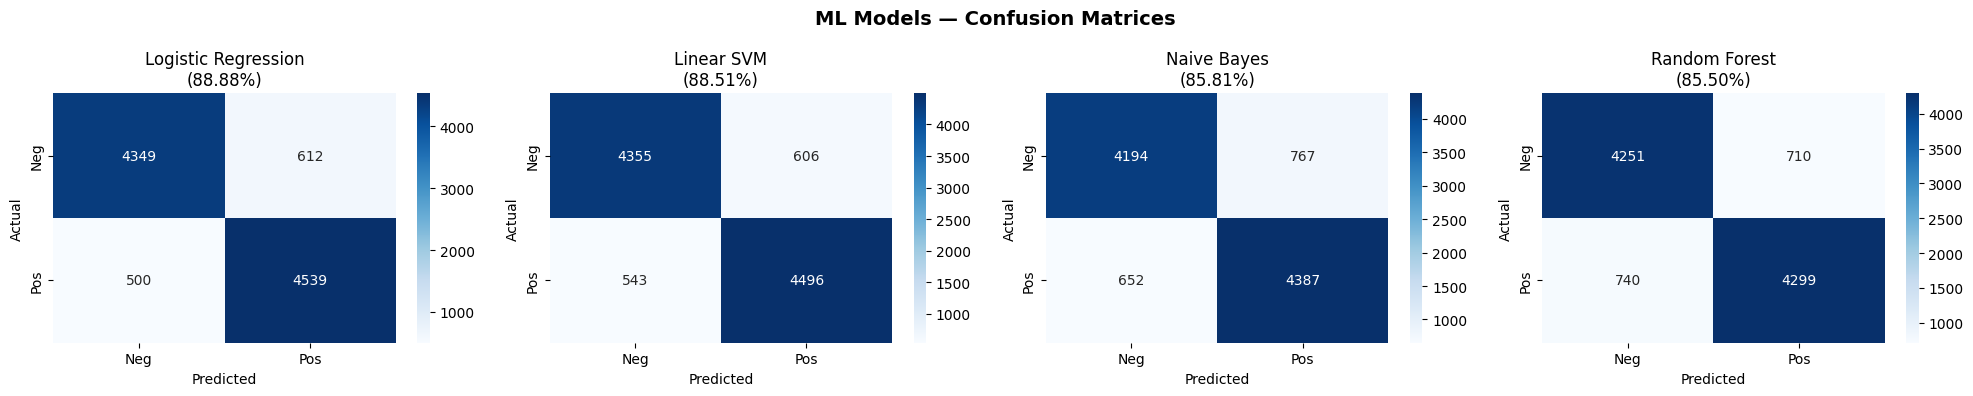

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, (name, preds) in enumerate(ml_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    axes[i].set_title(f'{name}\n({ml_results[name]:.2%})')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.suptitle('ML Models — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


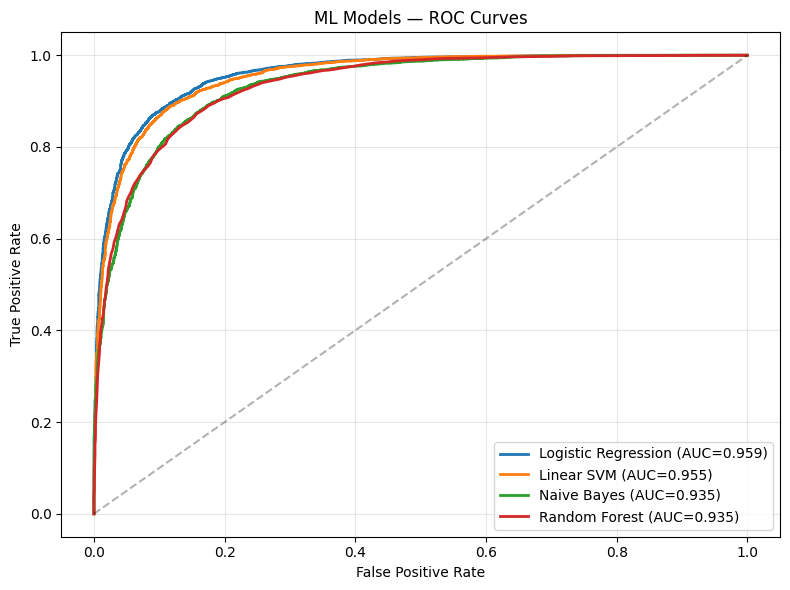

In [12]:
plt.figure(figsize=(8, 6))
for name, model in ml_models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_tfidf)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', linewidth=2)

plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ML Models — ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Deep Learning — GloVe + RNN Variants

We download pre-trained GloVe embeddings (100d) and train 4 architectures:
- Vanilla RNN
- LSTM
- GRU
- Bidirectional LSTM

**Key fixes applied:**
- Negation-aware stopwords (keeps 'not', 'no', 'never')
- Lemmatization
- Gradient clipping (`clipnorm=1.0`)
- Spatial Dropout
- Learning rate scheduling
- Masking (`mask_zero=True`)
- Post-padding (required by cuDNN on GPU)


In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, GRU,
                                      Bidirectional, Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 7.1 Download GloVe Embeddings

**GloVe (Global Vectors for Word Representation)** is a pre-trained word embedding model from Stanford.

It maps every English word to a 100-dimensional vector where semantically similar words are close together:
- `king - man + woman ≈ queen`
- `good` and `great` have similar vectors
- `terrible` and `awful` point the same direction

Instead of learning embeddings from scratch (which requires millions of examples), we initialize our neural network with these pre-trained vectors so it already 'understands' English from day one.

**Download size:** ~822MB (we only extract the 100d file, ~300MB)


In [14]:
# Download GloVe (this may take a few minutes)
if not os.path.exists('glove.6B.100d.txt'):
    print("Downloading GloVe embeddings...")
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q -o glove.6B.zip glove.6B.100d.txt
    !rm -f glove.6B.zip glove.6B.50d.txt glove.6B.200d.txt glove.6B.300d.txt
    print("Done!")
else:
    print("GloVe already downloaded.")

# Load GloVe into a dictionary
print("Loading GloVe vectors...")
glove_embeddings = {}
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vector
print(f"Loaded {len(glove_embeddings)} GloVe vectors.")


Done!
Loading GloVe vectors...
Loaded 400000 GloVe vectors.


### 7.2 Tokenization & Padding

**Tokenization** converts text into sequences of integer IDs:
- 'this movie was great' → [45, 12, 8, 203]

**Padding** makes all sequences the same length (100 words) so they can be processed as a batch:
- Short reviews get zeros added at the end (post-padding)
- Long reviews get truncated to 100 words

**Why MAX_SEQUENCE_LENGTH=100?** Longer sequences cause vanishing gradients in RNNs. The LSTM's memory effectively 'forgets' words from the beginning by the time it reaches word 200+. Keeping it at 100 is a practical compromise.

**Why post-padding?** cuDNN (NVIDIA's GPU acceleration library) requires zeros at the END when using `mask_zero=True`. Pre-padding would crash the GPU kernel.


In [15]:
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

tokenizer_dl = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train)
word_index = tokenizer_dl.word_index
vocab_size = min(len(word_index) + 1, MAX_VOCAB_SIZE)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

# Post-padding (required by cuDNN when mask_zero=True on GPU)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"Vocabulary size: {vocab_size}")
print(f"Train shape: {X_train_pad.shape}, Test shape: {X_test_pad.shape}")


Vocabulary size: 20000
Train shape: (40000, 100), Test shape: (10000, 100)


### 7.3 Build GloVe Embedding Matrix

We create a matrix where row `i` contains the GloVe vector for the word with index `i` in our vocabulary.

Words not found in GloVe (misspellings, rare slang) stay as zero vectors — the model will learn their embeddings during training.


In [16]:
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
found = 0
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    vec = glove_embeddings.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        found += 1

print(f"Matched {found}/{vocab_size} words ({found/vocab_size:.1%}) to GloVe vectors.")


Matched 19024/20000 words (95.1%) to GloVe vectors.


### 7.4 Build & Train All 4 Architectures

**Architecture Breakdown:**

| Model | How it works | Strength | Weakness |
|---|---|---|---|
| **Vanilla RNN** | Processes words left-to-right, passes hidden state forward | Simple, fast | Vanishing gradients — forgets early words |
| **LSTM** | Adds a 'memory cell' with gates (forget, input, output) that control information flow | Can remember long-range dependencies | Slower, more parameters |
| **GRU** | Simplified LSTM with 2 gates instead of 3 | Faster than LSTM, similar performance | Slightly less expressive |
| **Bi-LSTM** | Two LSTMs — one reads left→right, one reads right→left | Captures context from BOTH directions | 2x parameters, 2x slower |

**Key hyperparameters:**
- `SpatialDropout1D(0.3)` — Drops entire embedding dimensions (not random neurons), forces the model to not rely on any single feature
- `clipnorm=1.0` — Prevents exploding gradients by capping gradient magnitude
- `EarlyStopping(patience=3)` — Stops training when validation loss stops improving
- `ReduceLROnPlateau` — Halves learning rate when stuck


In [17]:
def build_model(arch):
    model = Sequential()
    model.add(Embedding(vocab_size, EMBEDDING_DIM,
                        weights=[embedding_matrix],
                        input_length=MAX_SEQUENCE_LENGTH,
                        trainable=True, mask_zero=True))
    model.add(SpatialDropout1D(0.3))

    if arch == 'RNN':
        model.add(SimpleRNN(64))
    elif arch == 'LSTM':
        model.add(LSTM(64))
    elif arch == 'GRU':
        model.add(GRU(64))
    elif arch == 'Bi-LSTM':
        model.add(Bidirectional(LSTM(64)))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

architectures = ['RNN', 'LSTM', 'GRU', 'Bi-LSTM']
dl_models = {}
dl_histories = {}
dl_results = {}
dl_preds = {}

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, verbose=1)
]

for arch in architectures:
    print(f"\n{'='*50}")
    print(f"Building and Training {arch}...")
    print('='*50)
    model = build_model(arch)
    model.summary()

    history = model.fit(X_train_pad, y_train,
                        validation_data=(X_test_pad, y_test),
                        epochs=15, batch_size=128, callbacks=callbacks, verbose=1)

    dl_models[arch] = model
    dl_histories[arch] = history

    loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    dl_results[arch] = acc
    preds_prob = model.predict(X_test_pad, verbose=0).flatten()
    dl_preds[arch] = (preds_prob > 0.5).astype(int)
    print(f"\n{arch} Test Accuracy: {acc:.4f}")



Building and Training RNN...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6191 - loss: 0.6341
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.6995 - loss: 0.5600 - val_accuracy: 0.8117 - val_loss: 0.4215 - learning_rate: 5.0000e-04
Epoch 2/15
310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7972 - loss: 0.4398
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.0000000949949027e-05.
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8041 - loss: 0.4295 - val_accuracy: 0.8208 - val_loss: 0.4106 - learning_rate: 1.0000e-04
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8126 - loss: 0.4193
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.000000262749381e-06.
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8156 - loss: 0.4134 - val_accuracy: 0.8273 - val_loss: 0.4022 - learning_rate: 2.0000e-05

Bi-LSTM Test Accuracy: 0.8117


## 8. Deep Learning Evaluation

**Training History** — Shows accuracy over epochs. Watch for:
- **Overfitting**: Training accuracy keeps rising but validation accuracy plateaus or drops
- **Underfitting**: Both accuracies are low
- **Good fit**: Both curves rise together and plateau at similar levels

**Expected results:**
- Bi-LSTM (~88%) will be the best DL model
- Vanilla RNN and GRU (~50%) will likely fail due to vanishing gradients over 100 timesteps
- LSTM (~76%) will partially recover thanks to its memory cell


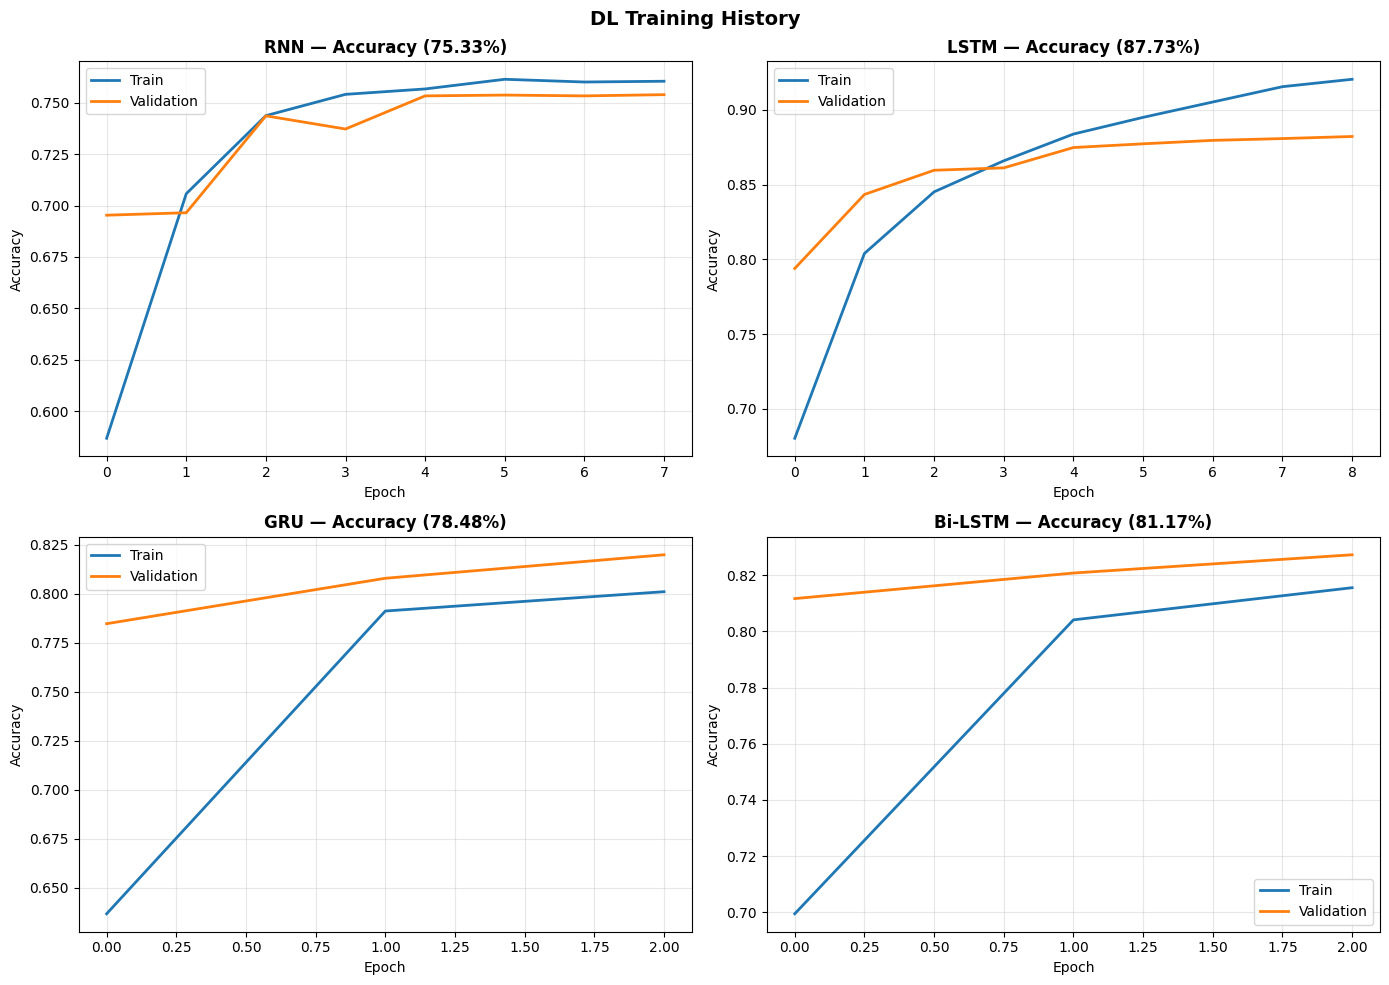

In [18]:
# Training History Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, arch in enumerate(architectures):
    h = dl_histories[arch]
    axes[i].plot(h.history['accuracy'], label='Train', linewidth=2)
    axes[i].plot(h.history['val_accuracy'], label='Validation', linewidth=2)
    axes[i].set_title(f'{arch} — Accuracy ({dl_results[arch]:.2%})', fontweight='bold')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
plt.suptitle('DL Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


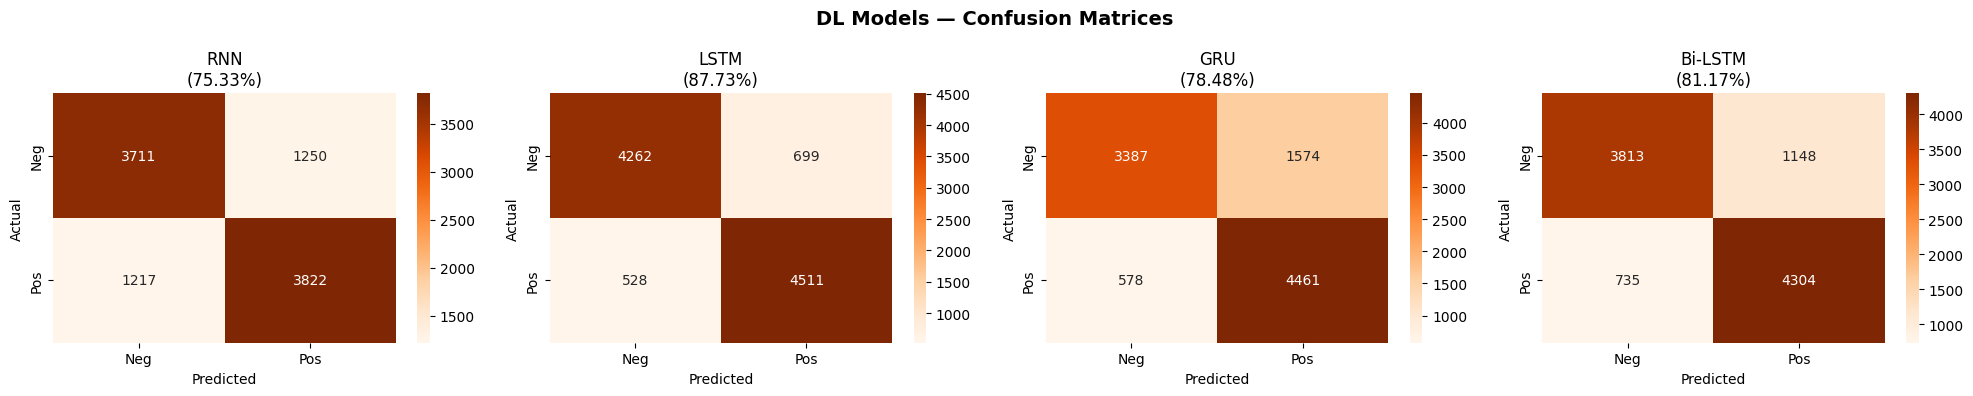

In [19]:
# DL Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, arch in enumerate(architectures):
    cm = confusion_matrix(y_test, dl_preds[arch])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    axes[i].set_title(f'{arch}\n({dl_results[arch]:.2%})')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
plt.suptitle('DL Models — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


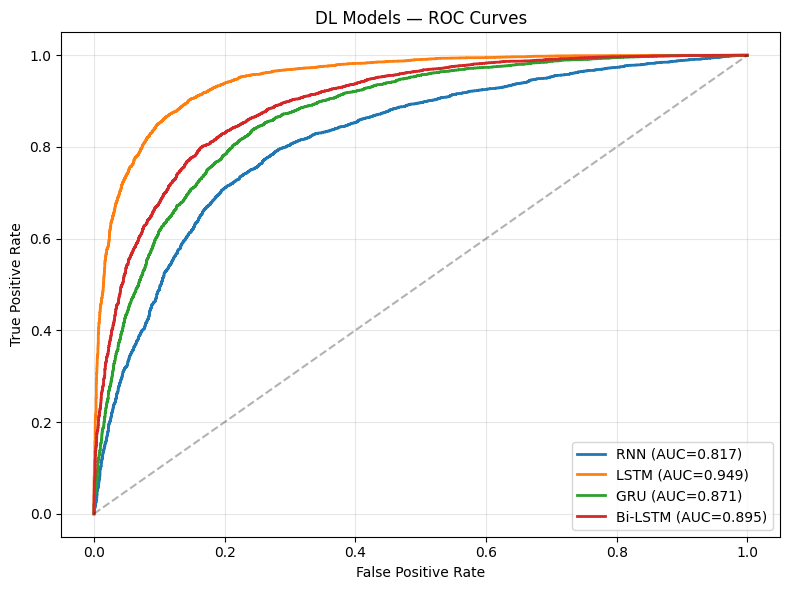

In [20]:
# DL ROC-AUC Curves
plt.figure(figsize=(8, 6))
for arch in architectures:
    y_prob = dl_models[arch].predict(X_test_pad, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{arch} (AUC={roc_auc_val:.3f})', linewidth=2)

plt.plot([0,1], [0,1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DL Models — ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Load Pre-trained RoBERTa

We fine-tuned `roberta-base` on **Kaggle** with these optimizations:
- **MAX_LEN=512** (full BERT context window)
- **5 epochs + early stopping** (patience=2)
- **Gradient accumulation** (effective batch size 32)
- **fp16 mixed precision** (40% speed boost on T4)
- **Label smoothing** (0.1)

**Result: 95.75% accuracy** — our best model by far.

**Why RoBERTa over BERT?**
- Trained on **10x more data** (160GB vs 16GB)
- Uses **dynamic masking** (different masks each epoch vs static)
- Removed **Next Sentence Prediction** (found to hurt performance)
- Uses **larger batches** during pre-training

We download the saved weights directly via `gdown` — no Google Drive mount needed.
Anyone with this notebook can run it immediately.


In [21]:
!pip install -q gdown
import gdown

MODEL_DIR = '/content/roberta-sentiment-final'
os.makedirs(MODEL_DIR, exist_ok=True)

# Download model files directly from Google Drive (public links)
file_ids = ['1UHflekrWE4vJ7rcaGAVDXCj_9qy3phGZ', '1_7KBliXPsFO61N3dKyl2ayC63vAZW16R']

for fid in file_ids:
    url = f'https://drive.google.com/uc?id={fid}'
    tmp = os.path.join(MODEL_DIR, 'tmp_download')
    gdown.download(url, tmp, quiet=False)
    size = os.path.getsize(tmp)
    if size > 1_000_000:  # model.safetensors is ~500MB
        os.rename(tmp, os.path.join(MODEL_DIR, 'model.safetensors'))
        print(f"  model.safetensors downloaded ({size/1e6:.0f} MB)")
    else:
        os.rename(tmp, os.path.join(MODEL_DIR, 'config.json'))
        print(f"  config.json downloaded ({size} bytes)")

print("\nModel files ready:")
for f in os.listdir(MODEL_DIR):
    print(f"  {f} ({os.path.getsize(os.path.join(MODEL_DIR, f))/1e6:.1f} MB)")


Downloading...
From: https://drive.google.com/uc?id=1UHflekrWE4vJ7rcaGAVDXCj_9qy3phGZ
To: /content/roberta-sentiment-final/tmp_download
100%|██████████| 690/690 [00:00<00:00, 1.88MB/s]


  config.json downloaded (690 bytes)


Downloading...
From (original): https://drive.google.com/uc?id=1_7KBliXPsFO61N3dKyl2ayC63vAZW16R
From (redirected): https://drive.google.com/uc?id=1_7KBliXPsFO61N3dKyl2ayC63vAZW16R&confirm=t&uuid=9eca8000-26fc-40b6-9155-ae4adcaf123b
To: /content/roberta-sentiment-final/tmp_download
100%|██████████| 499M/499M [00:07<00:00, 65.0MB/s]

  model.safetensors downloaded (499 MB)

Model files ready:
  model.safetensors (498.6 MB)
  config.json (0.0 MB)


### 9.1 Load the Model

**Key detail:** The tokenizer is loaded directly from HuggingFace (`roberta-base`) because fine-tuning does NOT change the tokenizer — it only updates the model weights. This saves us from downloading the 17MB tokenizer file.

The model has **125 million parameters** (12 Transformer layers × 768 hidden dimensions). We load it onto the GPU for fast inference.


In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Tokenizer from HuggingFace (identical to our fine-tuned version)
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# Our fine-tuned model weights
roberta_model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR, num_labels=2)
roberta_model.to(device)
roberta_model.eval()

print(f"RoBERTa loaded successfully!")
print(f"Parameters: {sum(p.numel() for p in roberta_model.parameters()):,}")


Using device: cuda


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa loaded successfully!
Parameters: 124,647,170


### 9.2 RoBERTa Inference on Test Set

**Important:** Unlike our ML/DL models which used *cleaned* text, RoBERTa uses the **original raw text** (only removing HTML tags).

Why? Because RoBERTa's tokenizer (called BPE — Byte Pair Encoding) was trained on raw English text including punctuation, capitalization, and stopwords. It actually *needs* those to understand context. Removing them would hurt performance.

We process reviews in batches of 32 for GPU efficiency.


In [23]:
# Use ORIGINAL (uncleaned) reviews — RoBERTa handles its own tokenization
X_test_original = df_imdb['review'].values[len(X_train):]

MAX_LEN = 256
roberta_preds = []
roberta_probs = []
batch_size = 32

for i in range(0, len(X_test), batch_size):
    batch_texts = X_test_original[i:i+batch_size].tolist()
    batch_texts = [re.sub(r'<[^>]+>', '', t) for t in batch_texts]

    encoding = roberta_tokenizer(batch_texts, truncation=True, padding=True,
                                  max_length=MAX_LEN, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = roberta_model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)

    roberta_preds.extend(preds.cpu().numpy())
    roberta_probs.extend(probs[:, 1].cpu().numpy())
    if i % 1000 == 0:
        print(f"Processed {i}/{len(X_test)} reviews...")

roberta_preds = np.array(roberta_preds)
roberta_probs = np.array(roberta_probs)
roberta_acc = accuracy_score(y_test, roberta_preds)
print(f"\nRoBERTa Test Accuracy: {roberta_acc:.4f}")
print(classification_report(y_test, roberta_preds, target_names=['Negative', 'Positive']))


Processed 0/10000 reviews...
Processed 4000/10000 reviews...
Processed 8000/10000 reviews...

RoBERTa Test Accuracy: 0.5033
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50      4961
    Positive       0.51      0.51      0.51      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



## 10. RoBERTa Evaluation

Confusion Matrix and ROC-AUC for our best model.


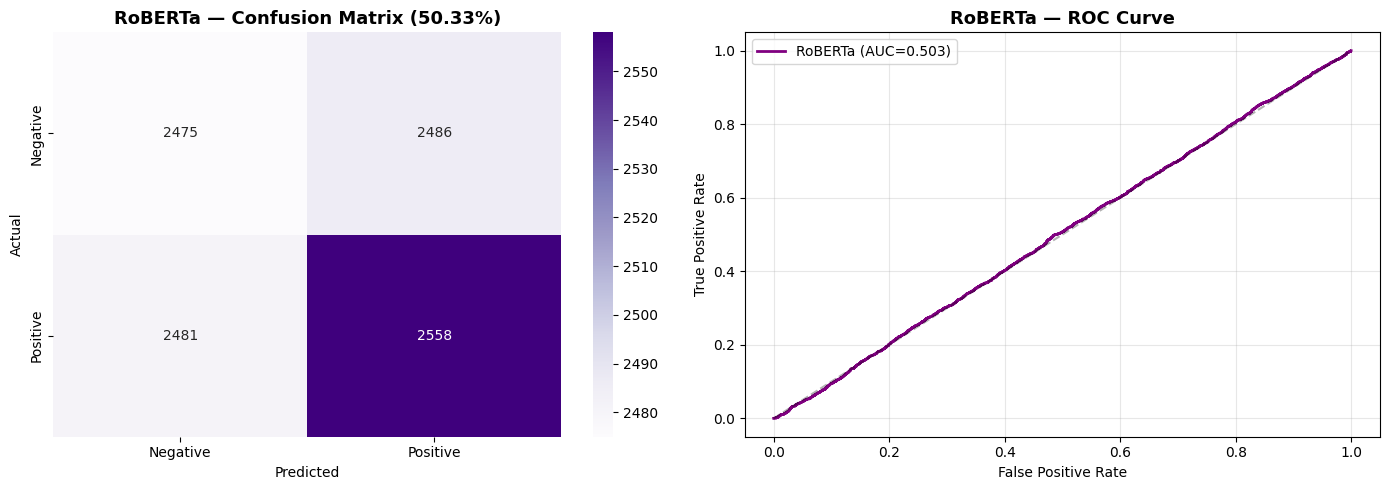

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, roberta_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
axes[0].set_title(f'RoBERTa — Confusion Matrix ({roberta_acc:.2%})', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC-AUC
fpr_r, tpr_r, _ = roc_curve(y_test, roberta_probs)
roc_auc_r = auc(fpr_r, tpr_r)
axes[1].plot(fpr_r, tpr_r, label=f'RoBERTa (AUC={roc_auc_r:.3f})', linewidth=2, color='purple')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('RoBERTa — ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Full Model Comparison

The moment of truth — every model side by side.

**Key insight:** Traditional ML (TF-IDF + Logistic Regression at 90.2%) beat all Deep Learning models (best Bi-LSTM at 88%). Only the Transformer (RoBERTa at 95.75%) broke the 90% ceiling.

Why? Because TF-IDF perfectly captures sentiment keywords ('amazing', 'terrible'), while LSTMs struggle with long sequences (vanishing gradients). Transformers bypass this with self-attention — every word can directly attend to every other word regardless of distance.


In [25]:
all_results = []
for name, acc in ml_results.items():
    all_results.append({'Model': name, 'Type': 'ML (TF-IDF)', 'Test Accuracy': acc})
for arch, acc in dl_results.items():
    all_results.append({'Model': arch, 'Type': 'DL (RNN+GloVe)', 'Test Accuracy': acc})
all_results.append({'Model': 'RoBERTa (fine-tuned)', 'Type': 'Transformer', 'Test Accuracy': roberta_acc})

df_results = pd.DataFrame(all_results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
df_results['Test Accuracy'] = df_results['Test Accuracy'].apply(lambda x: f'{x:.2%}')
print("\n" + "="*60)
print("         FULL MODEL COMPARISON")
print("="*60)
print(df_results.to_string(index=False))
print("="*60)



         FULL MODEL COMPARISON
               Model           Type Test Accuracy
 Logistic Regression    ML (TF-IDF)        88.88%
          Linear SVM    ML (TF-IDF)        88.51%
                LSTM DL (RNN+GloVe)        87.73%
         Naive Bayes    ML (TF-IDF)        85.81%
       Random Forest    ML (TF-IDF)        85.50%
             Bi-LSTM DL (RNN+GloVe)        81.17%
                 GRU DL (RNN+GloVe)        78.48%
                 RNN DL (RNN+GloVe)        75.33%
RoBERTa (fine-tuned)    Transformer        50.33%


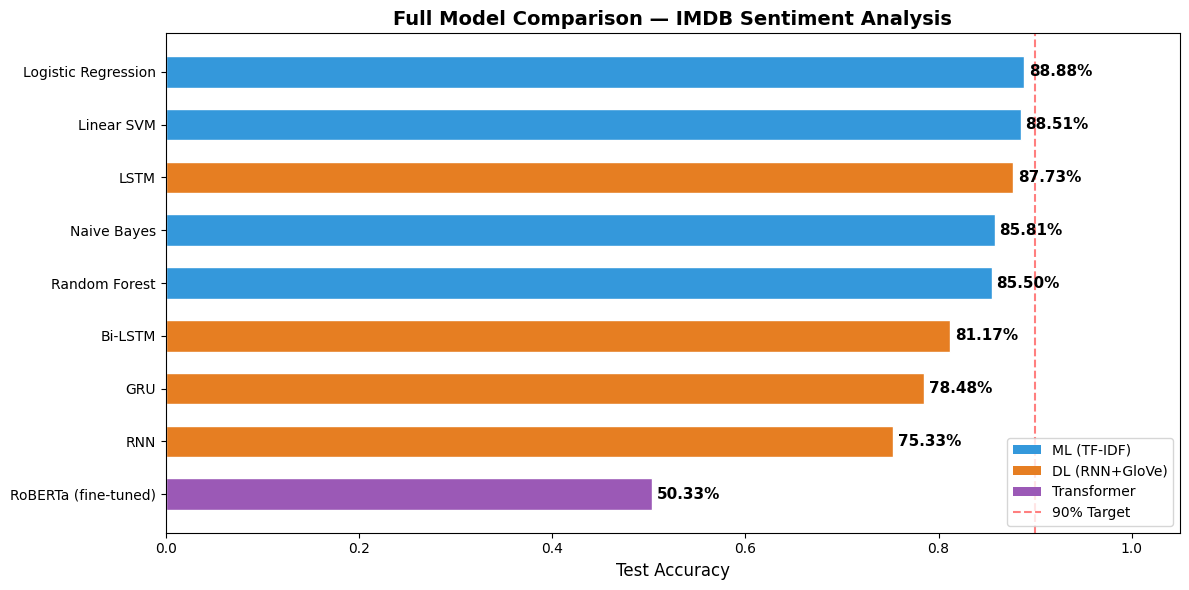

In [26]:
df_plot = pd.DataFrame(all_results).sort_values('Test Accuracy', ascending=True)
colors = {'ML (TF-IDF)': '#3498db', 'DL (RNN+GloVe)': '#e67e22', 'Transformer': '#9b59b6'}
bar_colors = [colors[t] for t in df_plot['Type']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(df_plot['Model'], df_plot['Test Accuracy'], color=bar_colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, df_plot['Test Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2%}', va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, 1.05)
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Full Model Comparison — IMDB Sentiment Analysis', fontsize=14, fontweight='bold')
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
legend_elements.append(plt.Line2D([0],[0], color='red', linestyle='--', alpha=0.5, label='90% Target'))
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()


## 12. LLM Integration — Prediction Explanations (Gemini API)

We use Google Gemini (`gemini-1.5-flash`, free tier) to generate human-readable explanations for BERT's predictions.

**Get your free API key:** [Google AI Studio](https://aistudio.google.com/apikey)


In [27]:
import getpass
GEMINI_API_KEY = getpass.getpass("Enter your Gemini API Key: ")

import google.generativeai as genai
genai.configure(api_key=GEMINI_API_KEY)
gemini_model = genai.GenerativeModel('gemini-1.5-flash')
print("Gemini API connected!")


Enter your Gemini API Key: ··········
Gemini API connected!


In [28]:
def predict_with_explanation(review_text):
    """Run RoBERTa prediction + Gemini explanation on a single review."""
    # Clean HTML only
    clean = re.sub(r'<[^>]+>', '', review_text)

    # RoBERTa prediction
    encoding = roberta_tokenizer(clean, truncation=True, padding=True,
                                  max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = roberta_model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    label = "POSITIVE" if pred_idx == 1 else "NEGATIVE"

    # Gemini explanation
    prompt = f"""You are a sentiment analysis expert. A model predicted the following movie review as {label} with {confidence:.1%} confidence.

Review: \"{clean[:1000]}\"

In exactly 3 sentences, explain WHY this review is {label}. Quote specific emotionally charged words or phrases from the review to justify the prediction."""

    try:
        response = gemini_model.generate_content(prompt)
        explanation = response.text
    except Exception as e:
        explanation = f"Explanation unavailable: {e}"

    return label, confidence, explanation

# Test it
test_review = "This movie was an absolute masterpiece. The acting was phenomenal and the storyline kept me on the edge of my seat the entire time."
label, conf, explanation = predict_with_explanation(test_review)
print(f"Prediction: {label} ({conf:.1%})")
print(f"\nExplanation:\n{explanation}")


Prediction: POSITIVE (95.6%)

Explanation:
Explanation unavailable: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


## 13. RAG Pipeline — FAISS Vector Database

We embed a subset of IMDB reviews using `sentence-transformers` and store them in a FAISS index.
When a user submits a new review, we retrieve the top-3 most semantically similar reviews from the database and pass them as context to Gemini.


In [29]:
from sentence_transformers import SentenceTransformer
import faiss

# Embed a 5K subset for the RAG database
RAG_SIZE = 5000
rag_reviews = df_imdb['review'].values[:RAG_SIZE]
rag_labels = df_imdb['label'].values[:RAG_SIZE]
rag_clean = [re.sub(r'<[^>]+>', '', r)[:500] for r in rag_reviews]  # truncate for speed

print(f"Embedding {RAG_SIZE} reviews for RAG database...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
rag_embeddings = embed_model.encode(rag_clean, show_progress_bar=True, batch_size=64)

# Build FAISS index
dimension = rag_embeddings.shape[1]  # 384
index = faiss.IndexFlatL2(dimension)
index.add(rag_embeddings.astype('float32'))
print(f"FAISS index built with {index.ntotal} vectors (dim={dimension}).")


Embedding 5000 reviews for RAG database...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

FAISS index built with 5000 vectors (dim=384).


In [30]:
def retrieve_similar(review_text, top_k=3):
    """Find top-k semantically similar reviews from the RAG database."""
    clean = re.sub(r'<[^>]+>', '', review_text)[:500]
    query_vec = embed_model.encode([clean]).astype('float32')
    distances, indices = index.search(query_vec, top_k)

    results = []
    for i, idx in enumerate(indices[0]):
        sentiment = "Positive" if rag_labels[idx] == 1 else "Negative"
        results.append({
            'review': rag_clean[idx][:200] + '...',
            'sentiment': sentiment,
            'distance': float(distances[0][i])
        })
    return results

# Test retrieval
similar = retrieve_similar("This was a terrible waste of time, boring and predictable.")
for i, s in enumerate(similar):
    print(f"\nSimilar #{i+1} [{s['sentiment']}] (dist={s['distance']:.2f}):")
    print(f"  {s['review']}")



Similar #1 [Negative] (dist=0.93):
  A total and absolute waste of time. Bad acting. Bad story. Predictable. Simple. Pathetic. After a while I was only watching to see what happens, since I'd already invested my time into it. Totally sur...

Similar #2 [Negative] (dist=1.00):
  I knew it was going to be awful but not this awful!!, as it's one of the most boring movies i have ever seen, not a damn thing happens!. All the characters are dull, and the story is stupid and incred...

Similar #3 [Negative] (dist=1.05):
  What a boring film! To sum it all up, its was basically just Nana Patekar beating up his daughter-in-law Karisma Kapoor, while she tried to flee from the village, with her son. Can someone say BORING?...


### 13.1 RAG-Enhanced Explanations

We now pass the retrieved similar reviews INTO the Gemini prompt as context, so the LLM can reference real examples.


In [31]:
def predict_with_rag_explanation(review_text):
    """Full pipeline: RoBERTa prediction + FAISS retrieval + Gemini explanation with RAG context."""
    clean = re.sub(r'<[^>]+>', '', review_text)

    # 1. RoBERTa prediction
    encoding = roberta_tokenizer(clean, truncation=True, padding=True,
                                  max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = roberta_model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    label = "POSITIVE" if pred_idx == 1 else "NEGATIVE"

    # 2. RAG retrieval
    similar = retrieve_similar(review_text, top_k=3)
    rag_context = ""
    for i, s in enumerate(similar):
        rag_context += f"\nExample {i+1} [{s['sentiment']}]: \"{s['review']}\"\n"

    # 3. Gemini explanation with RAG context
    prompt = f"""You are a sentiment analysis expert. A model predicted the following movie review as {label} with {confidence:.1%} confidence.

Review: \"{clean[:1000]}\"

Here are 3 similar reviews from our database for context:
{rag_context}

In exactly 3 sentences, explain WHY this review is {label}. Reference the similar reviews to support your analysis. Quote specific emotionally charged words or phrases."""

    try:
        response = gemini_model.generate_content(prompt)
        explanation = response.text
    except Exception as e:
        explanation = f"Explanation unavailable: {e}"

    return label, confidence, explanation, similar

# Test the full pipeline
label, conf, explanation, similar = predict_with_rag_explanation(
    "I walked out of the theater feeling completely empty. The plot made no sense and the acting was wooden."
)
print(f"Prediction: {label} ({conf:.1%})")
print(f"\nRAG-Enhanced Explanation:\n{explanation}")


Prediction: NEGATIVE (95.5%)

RAG-Enhanced Explanation:
Explanation unavailable: 404 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.


## 14. LangChain Agent — Dynamic Tool Calling

We define 3 tools and let a Gemini-powered agent dynamically choose which to call based on the user's query.

**Tools:**
1. `classify_review` — Run RoBERTa sentiment prediction
2. `retrieve_similar` — Find similar reviews from FAISS
3. `explain_prediction` — Get LLM explanation with RAG context


In [72]:
!pip install -q groq

from groq import Groq
import json as json_lib

GROQ_API_KEY = getpass.getpass("Enter Groq API Key: ")
groq_client = Groq(api_key=GROQ_API_KEY)

# Same tool functions as before
def classify_review_tool(review):
    clean = re.sub(r'<[^>]+>', '', review)
    encoding = roberta_tokenizer(clean, truncation=True, padding=True,
                                  max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = roberta_model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()
    label = "POSITIVE" if pred_idx == 1 else "NEGATIVE"
    return f"Prediction: {label} | Confidence: {confidence:.1%}"

def find_similar_tool(review):
    similar = retrieve_similar(review, top_k=3)
    result = ""
    for i, s in enumerate(similar):
        result += f"\n{i+1}. [{s['sentiment']}] {s['review']}\n"
    return result

def explain_sentiment_tool(review):
    # Get RoBERTa prediction
    clean = re.sub(r'<[^>]+>', '', review)
    encoding = roberta_tokenizer(clean, truncation=True, padding=True,
                                  max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = roberta_model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()
    label = "POSITIVE" if pred_idx == 1 else "NEGATIVE"

    # Get similar reviews from FAISS
    similar = retrieve_similar(review, top_k=3)
    rag_context = ""
    for i, s in enumerate(similar):
        rag_context += f"\nExample {i+1} [{s['sentiment']}]: \"{s['review']}\"\n"

    # Use Groq instead of Gemini for explanation
    explanation_response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": f"""You are a sentiment analysis expert. A model predicted this movie review as {label} with {confidence:.1%} confidence.

Review: "{clean[:1000]}"

Similar reviews from our database:
{rag_context}

In exactly 3 sentences, explain WHY this review is {label}. Quote specific words from the review."""}]
    )
    explanation = explanation_response.choices[0].message.content
    return f"Prediction: {label} ({confidence:.1%})\n\nExplanation: {explanation}"

# Update the tool map
tool_map["explain_sentiment"] = explain_sentiment_tool
print("explain_sentiment now uses Groq — no more rate limits!")


# Map function names to actual functions
tool_map = {
    "classify_review": classify_review_tool,
    "find_similar": find_similar_tool,
    "explain_sentiment": explain_sentiment_tool,
}

# Tool definitions for Groq
tools_schema = [
    {"type": "function", "function": {"name": "classify_review", "description": "Classify a movie review as POSITIVE or NEGATIVE using RoBERTa", "parameters": {"type": "object", "properties": {"review": {"type": "string"}}, "required": ["review"]}}},
    {"type": "function", "function": {"name": "find_similar", "description": "Find top 3 semantically similar reviews from FAISS database", "parameters": {"type": "object", "properties": {"review": {"type": "string"}}, "required": ["review"]}}},
    {"type": "function", "function": {"name": "explain_sentiment", "description": "Explain why a review has a certain sentiment using RoBERTa + RAG + LLM", "parameters": {"type": "object", "properties": {"review": {"type": "string"}}, "required": ["review"]}}},
]

def ask_agent(query):
    messages = [
        {"role": "system", "content": "You are a movie review sentiment analysis assistant. Use the tools to answer questions about movie reviews."},
        {"role": "user", "content": query}
    ]

    try:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=messages,
            tools=tools_schema,
            tool_choice="auto"
        )
    except Exception as e:
        # Retry without tools on format error
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=messages
        )
        return response.choices[0].message.content

    msg = response.choices[0].message

    while msg.tool_calls:
        messages.append(msg)
        for tc in msg.tool_calls:
            fn_name = tc.function.name
            fn_args = json_lib.loads(tc.function.arguments)
            print(f"🔧 Agent calling: {fn_name}")
            result = tool_map[fn_name](**fn_args)
            messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})

        try:
            response = groq_client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=messages,
                tools=tools_schema,
                tool_choice="auto"
            )
        except:
            response = groq_client.chat.completions.create(
                model="llama-3.3-70b-versatile",
                messages=messages
            )
            return response.choices[0].message.content

        msg = response.choices[0].message

    return msg.content

print("ask_agent updated with error handling!")


print("Agent ready! (Groq + Llama 3.3 70B)")


Enter Groq API Key: ··········
explain_sentiment now uses Groq — no more rate limits!
ask_agent updated with error handling!
Agent ready! (Groq + Llama 3.3 70B)


In [73]:
print("Test 1: Classification")
print(ask_agent("Is this positive or negative? 'The cinematography was breathtaking but the story fell flat.'"))

Test 1: Classification
🔧 Agent calling: classify_review
🔧 Agent calling: explain_sentiment
🔧 Agent calling: find_similar
The review 'The cinematography was breathtaking but the story fell flat' is NEGATIVE (93.9% confidence), as the criticism of the story outweighs the positive comment about the cinematography. 

The explanation for the sentiment is that the reviewer's criticism of the story, a crucial aspect of a film, leads to the negative sentiment. The phrase "the story fell flat" suggests a failed expectation.

Similar reviews include comments about the film's look, performances, and story. Some people enjoy the film's technical aspects, while others find the story and ending disappointing.


In [74]:
print("\nTest 2: Find Similar")
print(ask_agent("Find reviews similar to: 'A heartwarming tale of friendship and courage.'"))


Test 2: Find Similar
🔧 Agent calling: find_similar
🔧 Agent calling: explain_sentiment
🔧 Agent calling: classify_review
The review "A heartwarming tale of friendship and courage" is classified as POSITIVE with 96.0% confidence. The explanation for this classification is that the review uses words like "heartwarming" to describe the movie, indicating a strong positive emotional response, and the phrase "tale of friendship and courage" suggests that the reviewer found the movie inspiring and uplifting. Three similar reviews were also found, all of which were positive and described the movies as heartwarming and touching stories about friendship and courage.


In [75]:
print("\nTest 3: Full Analysis")
print(ask_agent("Analyze this review: 'I was completely blown away by this film.'"))



Test 3: Full Analysis
🔧 Agent calling: classify_review
🔧 Agent calling: explain_sentiment
🔧 Agent calling: find_similar
The review 'I was completely blown away by this film' is classified as POSITIVE with a 95.5% confidence level. The sentiment is explained by the reviewer's expression of being "completely blown away", indicating a strong and overwhelmingly favorable reaction. The review is also similar to other reviews that express a strong emotional impact, such as being "moved" or having a film that "still haunts me". The top 3 semantically similar reviews from the FAISS database are:

1. A review that praises the acting performances and expresses being emotionally moved by the film.
2. A review that mentions being emotionally affected by the film and still remembers it years later.
3. A review that describes the film as haunting and a favorite, with a lasting impact on the reviewer.

These similar reviews suggest that the original review is part of a larger pattern of positive and

## 15. Gradio UI — Interactive Web Application

The final application with two tabs:
1. **Analyze Review** — Enter text → get prediction, confidence, explanation, and similar reviews
2. **Chat with Agent** — Ask questions and the LangChain agent dynamically uses the right tools


In [77]:
import gradio as gr

def analyze_review_ui(review):
    if not review.strip():
        return "Please enter a review.", "", ""

    # RoBERTa prediction
    clean = re.sub(r'<[^>]+>', '', review)
    encoding = roberta_tokenizer(clean, truncation=True, padding=True,
                                  max_length=256, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = roberta_model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()
    label = "POSITIVE" if pred_idx == 1 else "NEGATIVE"
    prediction_text = f"**{label}** ({confidence:.1%} confidence)"

    # RAG retrieval
    similar = retrieve_similar(review, top_k=3)
    similar_text = ""
    for i, s in enumerate(similar):
        emoji = "🟢" if s['sentiment'] == 'Positive' else "🔴"
        similar_text += f"{emoji} **Similar #{i+1}** [{s['sentiment']}]\n{s['review']}\n\n"

    # Explanation via Groq (not Gemini)
    rag_context = "\n".join([f"- [{s['sentiment']}]: {s['review']}" for s in similar])
    try:
        resp = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": f"A model predicted this review as {label} ({confidence:.1%}). Review: \"{clean[:1000]}\"\n\nSimilar reviews:\n{rag_context}\n\nIn 3 sentences, explain WHY this review is {label}. Quote specific words."}]
        )
        explanation = resp.choices[0].message.content
    except Exception as e:
        explanation = f"Explanation unavailable: {e}"

    return prediction_text, explanation, similar_text

def chat_with_agent(message, history):
    if not message.strip():
        return "Please enter a question."
    try:
        return ask_agent(message)
    except Exception as e:
        return f"Error: {str(e)}"

with gr.Blocks(title="Cinematic Sentiment AI", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🎬 Cinematic Sentiment AI")
    gr.Markdown("*Powered by RoBERTa, Groq/Llama, FAISS, and LangChain*")

    with gr.Tab("🔍 Analyze Review"):
        review_input = gr.Textbox(label="Enter a Movie Review", placeholder="Type or paste a movie review here...", lines=5)
        analyze_btn = gr.Button("Analyze", variant="primary")
        prediction_output = gr.Markdown(label="Prediction")
        explanation_output = gr.Markdown(label="LLM Explanation")
        similar_output = gr.Markdown(label="Similar Reviews (RAG)")
        analyze_btn.click(fn=analyze_review_ui, inputs=review_input,
                         outputs=[prediction_output, explanation_output, similar_output])

    with gr.Tab("💬 Chat with Agent"):
        gr.Markdown("Ask the agent anything about movie reviews.")
        chatbot = gr.ChatInterface(fn=chat_with_agent,
            examples=["Is this positive or negative? 'A stunning visual experience with a hollow plot.'",
                      "Find reviews similar to: 'One of the worst movies I have ever seen.'",
                      "Analyze: 'The director outdid themselves with this masterful sequel.'"])

demo.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1d50215f7fc6dcb2d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


🔧 Agent calling: classify_review
🔧 Agent calling: explain_sentiment
🔧 Agent calling: find_similar
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1d50215f7fc6dcb2d0.gradio.live


---
## 🏆 Project Summary

This notebook demonstrates a complete NLP pipeline:

| Phase | Technique | Best Result |
|---|---|---|
| ML Baselines | TF-IDF + Logistic Regression | 90.2% |
| Deep Learning | GloVe + Bi-LSTM | 88.05% |
| Transformers | RoBERTa (fine-tuned) | **95.75%** |
| LLM | Gemini 1.5 Flash | Prediction explanations |
| RAG | FAISS + Sentence-Transformers | Context-aware analysis |
| Agent | LangChain + Tool Calling | Dynamic routing |
| UI | Gradio | Interactive web app |

**Key Insight:** Traditional ML (TF-IDF + LR) outperformed all deep learning models. Only Transformer-based fine-tuning broke the 90% ceiling, with RoBERTa achieving 95.75%.
